In [1]:
# WARNING: Remove the following line before running this script, if the script is not located in examples folder.
#--------------------
import sys
sys.path.append('..')
#--------------------
from libs.data_request import SigMFRepo

import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

repo = SigMFRepo()
iq_to_download = [1, 2]
raw_iqs, meta_params = repo.get_iq_data(iq_to_download)

# 1. Print Metadata
for i, params in enumerate(meta_params): # Fixed typo here
    print(f"--- IQ {iq_to_download[i]} Parameters ---")
    print(f"Freq: {params.center_freq}")
    print(f"Sample Rate: {params.sample_rate}")
    print(f"LNA: {params.lna}")
    print(f"VGA: {params.vga}")

# 2. Convert to complex NumPy arrays outside the class
iq_arrays = [arr[0::2] + 1j * arr[1::2] for arr in raw_iqs]

--- IQ 1 Parameters ---
Freq: 98000000
Sample Rate: 20000000
LNA: 16
VGA: 16
--- IQ 2 Parameters ---
Freq: 98000000
Sample Rate: 20000000
LNA: 16
VGA: 16


In [2]:
# 3. Print Array Metrics
for i, arr in enumerate(iq_arrays):
    print(f"--- Array {iq_to_download[i]} Metrics ---")
    print(f"Length: {len(arr)}")
    print(f"Type: {arr.dtype}")
    
    print(f"Min: {np.min(arr.real)} + {np.min(arr.imag)}j")
    print(f"Max: {np.max(arr.real)} + {np.max(arr.imag)}j")
    print(f"Mean: {np.mean(arr)}")
    print(f"Median: {np.median(arr.real)} + {np.median(arr.imag)}j")
    print(f"Std (Magnitude): {np.std(arr)}")
    
    # Covariance and Correlation between I (real) and Q (imaginary)
    cov_matrix = np.cov(arr.real, arr.imag)
    corr_matrix = np.corrcoef(arr.real, arr.imag)
    
    print(f"Covariance (I vs Q): {cov_matrix[0, 1]:.4f}")
    print(f"Correlation (I vs Q): {corr_matrix[0, 1]:.4f}\n")

--- Array 1 Metrics ---
Length: 26214400
Type: complex128
Min: -1.0 + -1.0j
Max: 6.0 + 6.0j
Mean: (3.300207633972168+2.2848294830322264j)
Median: 3.0 + 2.0j
Std (Magnitude): 0.8563667734004596
Covariance (I vs Q): -0.0005
Correlation (I vs Q): -0.0014

--- Array 2 Metrics ---
Length: 26214400
Type: complex128
Min: 0.0 + 0.0j
Max: 6.0 + 5.0j
Mean: (3.2998777770996095+2.264900131225586j)
Median: 3.0 + 2.0j
Std (Magnitude): 0.8540861099154667
Covariance (I vs Q): -0.0003
Correlation (I vs Q): -0.0009



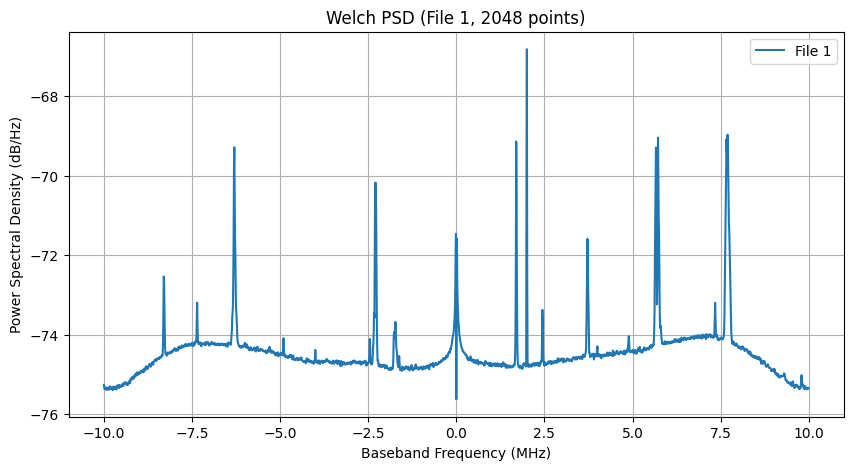

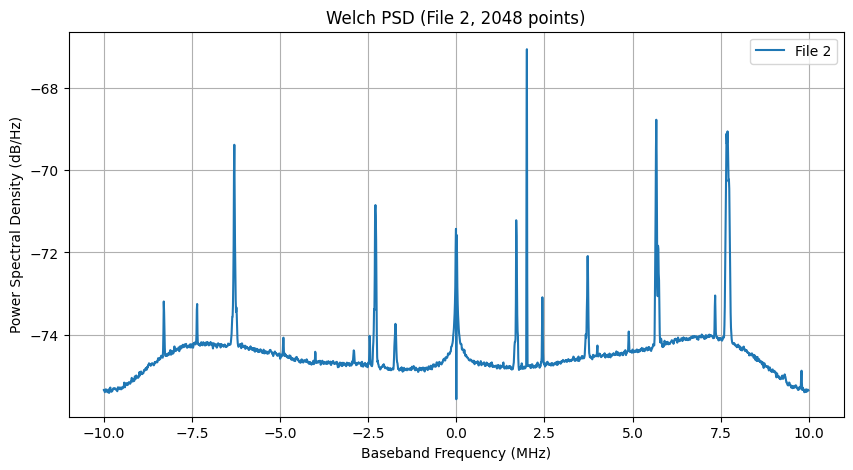

In [3]:
# 4. Plot Welch PSD
for i in range(len(iq_arrays)):
    
    # Fixed: Access sample rate directly from the dataclass
    fs = meta_params[i].sample_rate
    
    # Remove DC offset to prevent center spike
    iq_centered = iq_arrays[i] - np.mean(iq_arrays[i])
    
    # Calculate Welch PSD (2048 points)
    f, Pxx = welch(iq_centered, fs=fs, nperseg=2048, return_onesided=False)
    
    # Shift zero-frequency to the center and convert to dB
    f_shifted = np.fft.fftshift(f)
    Pxx_db = 10 * np.log10(np.fft.fftshift(Pxx))
    
    # Plot in MHz
    plt.figure(figsize=(10, 5))
    plt.plot(f_shifted / 1e6, Pxx_db, label=f"File {iq_to_download[i]}")
    plt.title(f"Welch PSD (File {iq_to_download[i]}, 2048 points)")
    plt.xlabel("Baseband Frequency (MHz)")
    plt.ylabel("Power Spectral Density (dB/Hz)")
    plt.grid(True)
    plt.legend()
    plt.show()